# Pneumonia Detection from Chest X-ray Images

**Dataset:** Chest X-ray Balanced Dataset  
**Source:** https://www.kaggle.com/datasets/umitka/chest-x-ray-balanced  
**Task:** Binary classification - Normal vs Pneumonia  

# 1. Setup and Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
import random

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
random.seed(42)
np.random.seed(42)

BASE_DIR = Path("chest_xray_balanced")
SPLITS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]

## 2. Load the Dataset

Build one master table listing every image file, its split (train/val/test), 
and its class (NORMAL/PNEUMONIA). This table is reused in every step below.

In [2]:
def load_dataset_index(base_dir, splits, classes):
    records = []
    for split in splits:
        for cls in classes:
            folder = base_dir / split / cls
            if not folder.exists():
                print(f"WARNING: missing folder {folder}")
                continue
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    records.append({
                        "filename": fname,
                        "filepath": str(folder / fname),
                        "split": split,
                        "class": cls
                    })
    return pd.DataFrame(records)

df = load_dataset_index(BASE_DIR, SPLITS, CLASSES)
print(f"Total images loaded: {len(df)}")
df.head()

Total images loaded: 9600


,filename,filepath,split,class
0,augmented_1000.jpg,chest_xray_balanced\train\NORMAL\augmented_100...,train,NORMAL
1,augmented_1001.jpg,chest_xray_balanced\train\NORMAL\augmented_100...,train,NORMAL
2,augmented_1002.jpg,chest_xray_balanced\train\NORMAL\augmented_100...,train,NORMAL
3,augmented_1003.jpg,chest_xray_balanced\train\NORMAL\augmented_100...,train,NORMAL
4,augmented_1004.jpg,chest_xray_balanced\train\NORMAL\augmented_100...,train,NORMAL


In [3]:
# Quick counts
print(df.groupby(['split', 'class']).size())

split  class    
test   NORMAL        400
       PNEUMONIA     400
train  NORMAL       4000
       PNEUMONIA    4000
val    NORMAL        400
       PNEUMONIA     400
dtype: int64


## 3. Data Cleaning

Before analyzing anything, verifying the data is trustworthy:
- Check for corrupted/unreadable images
- Check for duplicate files
- Check for suspiciously small/broken files

In [4]:
# 3.1 Check for corrupted images
def check_corrupted(filepath):

    try:
        with Image.open(filepath) as img:
            img.verify()
        return True
    except Exception:
        return False

df['is_valid'] = df['filepath'].apply(check_corrupted)
print(f"Corrupted images found: {(~df['is_valid']).sum()}")

Corrupted images found: 0


In [5]:
# 3.2 Check for duplicates
duplicates = df[df.duplicated(subset=['filepath'], keep=False)]
print(f"Duplicate files found: {len(duplicates)}")

Duplicate files found: 0


In [6]:
# 3.3 Check for tiny/broken files
df['filesize_kb'] = df['filepath'].apply(lambda p: os.path.getsize(p) / 1024)
tiny_files = df[df['filesize_kb'] < 1]

print(f"Suspiciously small files: {len(tiny_files)}")
df['filesize_kb'].describe()

Suspiciously small files: 0


count    9600.000000
mean      756.570611
std       886.791326
min         5.313477
25%        84.482666
50%       488.622070
75%      1100.679932
max      6975.006836
Name: filesize_kb, dtype: float64

In [7]:
# 3.4 Remove problem files, keep only the clean dataset
df_clean = df[df['is_valid']].drop_duplicates(subset=['filepath']).copy()
df_clean = df_clean[df_clean['filesize_kb'] >= 1]

print(f"Before cleaning: {len(df)}")
print(f"After cleaning:  {len(df_clean)}")

Before cleaning: 9600
After cleaning:  9600


## 4. Exploration & Visualization

Now that the data is verified clean, exploring it visually

### 4.1 Class Distribution

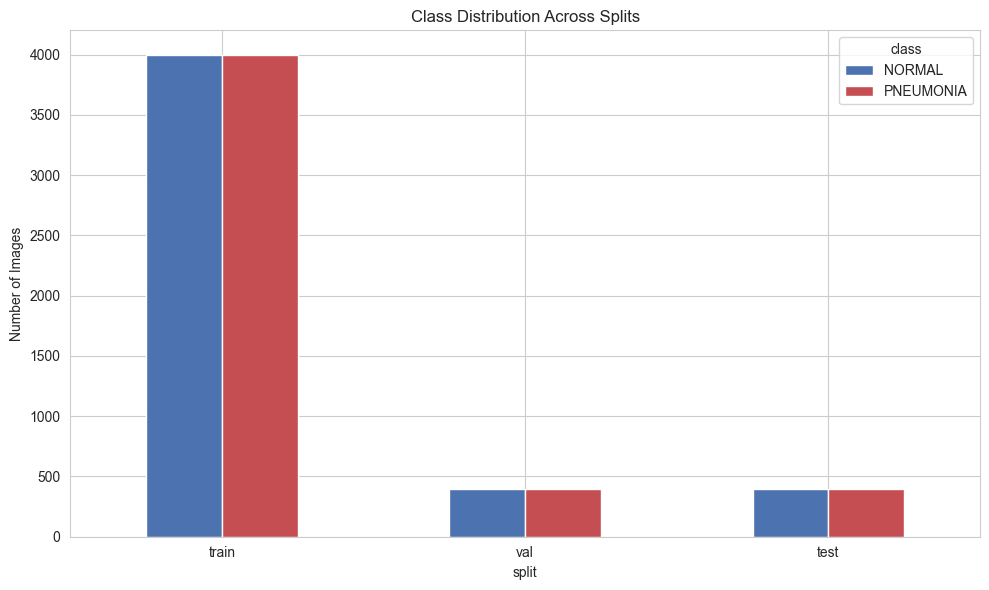

In [8]:
pivot_counts = df_clean.groupby(['split', 'class']).size().unstack().reindex(SPLITS)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Class Distribution Across Splits")
ax.set_ylabel("Number of Images")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Sample Images

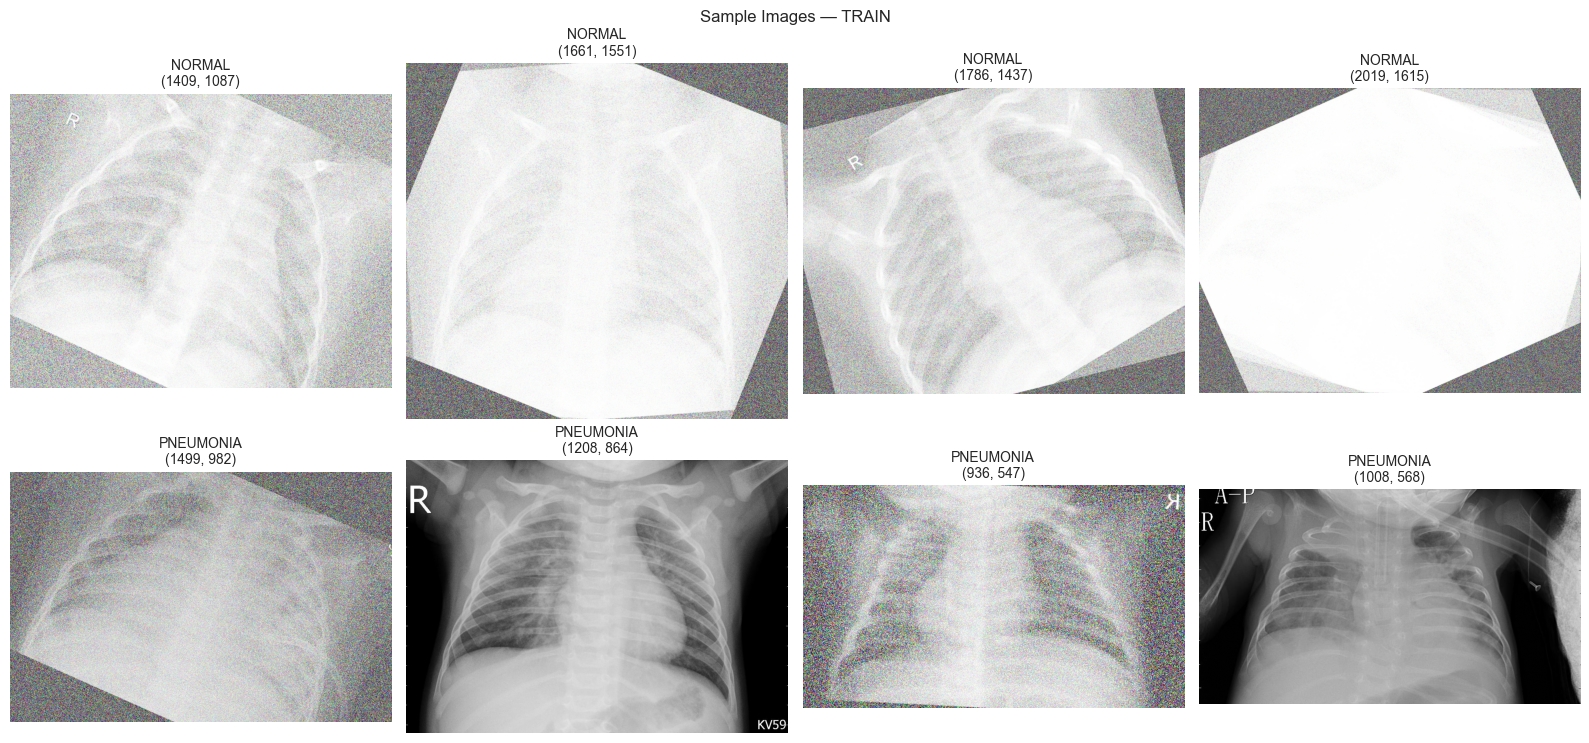

In [9]:
def show_samples(data, split="train", n_samples=4):
    fig, axes = plt.subplots(2, n_samples, figsize=(16, 8))
    for row, cls in enumerate(CLASSES):
        subset = data[(data['split'] == split) & (data['class'] == cls)]
        paths = subset['filepath'].sample(n_samples, random_state=1).tolist()
        for col, path in enumerate(paths):
            img = Image.open(path)
            axes[row, col].imshow(img, cmap="gray")
            axes[row, col].set_title(f"{cls}\n{img.size}", fontsize=10)
            axes[row, col].axis("off")
            
    plt.suptitle(f"Sample Images — {split.upper()}")
    plt.tight_layout()
    plt.show()

show_samples(df_clean, split="train")

### 4.3 Image Dimensions & Color Mode

In [10]:
def inspect_images(data, sample_size=300):

    sample = data.sample(min(sample_size, len(data)), random_state=1)
    results = []
    for _, row in sample.iterrows():
        with Image.open(row['filepath']) as img:
            results.append({
                "class": row['class'], "width": img.size[0],
                "height": img.size[1], "mode": img.mode
            })

    return pd.DataFrame(results)

dim_df = inspect_images(df_clean)
print(dim_df[["width", "height"]].describe())
print(f"\nColor modes: {dim_df['mode'].value_counts().to_dict()}")

             width       height
count   300.000000   300.000000
mean   1459.910000  1143.646667
std     398.817913   426.956956
min     415.000000   178.000000
25%    1194.500000   870.250000
50%    1456.500000  1113.500000
75%    1681.500000  1363.000000
max    2678.000000  2628.000000

Color modes: {'L': 151, 'RGB': 149}


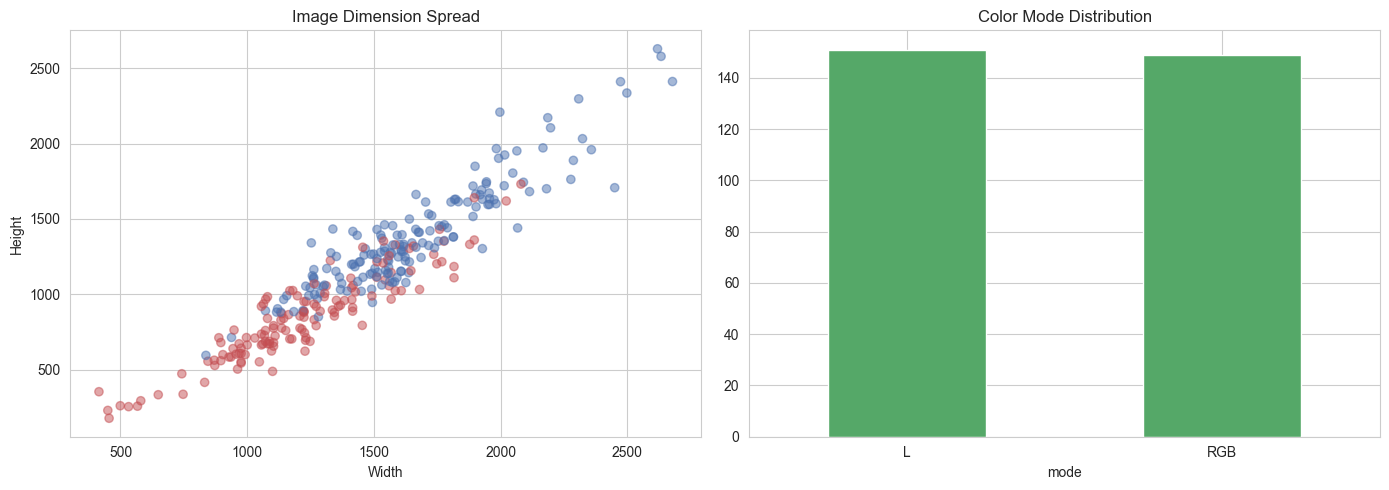

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(dim_df["width"], dim_df["height"],
                c=dim_df["class"].map({"NORMAL": "#4C72B0", "PNEUMONIA": "#C44E52"}), alpha=0.5)
axes[0].set_title("Image Dimension Spread")
axes[0].set_xlabel("Width"); axes[0].set_ylabel("Height")

dim_df["mode"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Color Mode Distribution")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.4 Pixel Intensity Distribution

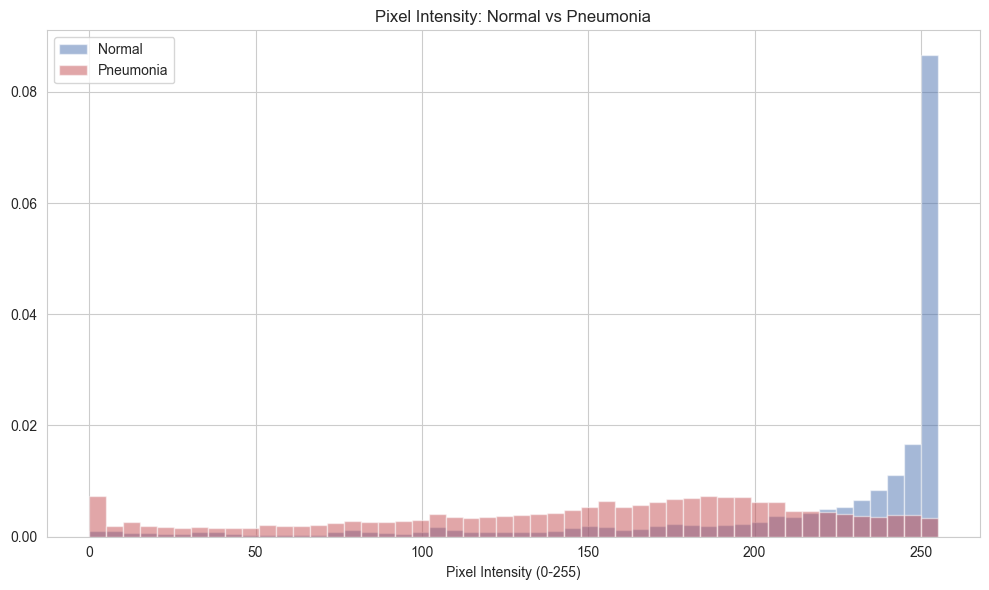

Normal mean: 218.46
Pneumonia mean: 147.40


In [12]:
def get_pixel_intensities(data, split="train", sample_size=100):
    intensities = {"NORMAL": [], "PNEUMONIA": []}
    for cls in CLASSES:
        subset = data[(data['split'] == split) & (data['class'] == cls)]
        paths = subset['filepath'].sample(min(sample_size, len(subset)), random_state=1).tolist()
        for path in paths:
            arr = np.array(Image.open(path).convert("L"))
            intensities[cls].extend(arr.flatten()[::50])
    return intensities

intensities = get_pixel_intensities(df_clean)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(intensities["NORMAL"], bins=50, alpha=0.5, label="Normal", color="#4C72B0", density=True)
ax.hist(intensities["PNEUMONIA"], bins=50, alpha=0.5, label="Pneumonia", color="#C44E52", density=True)
ax.set_xlabel("Pixel Intensity (0-255)")
ax.set_title("Pixel Intensity: Normal vs Pneumonia")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Normal mean: {np.mean(intensities['NORMAL']):.2f}")
print(f"Pneumonia mean: {np.mean(intensities['PNEUMONIA']):.2f}")

### 4.5 Average Image per Class

Averaging many images per class can reveal systematic visual differences.

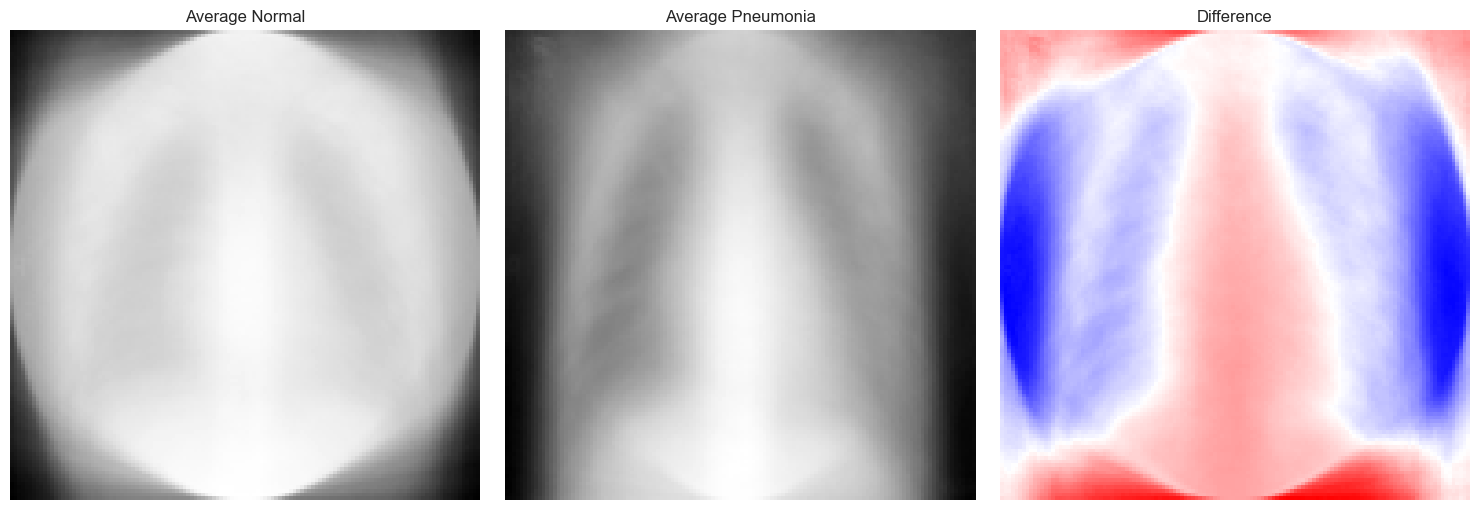

In [13]:
def compute_mean_image(data, cls, split="train", img_size=(128,128), sample_size=200):
    subset = data[(data['split'] == split) & (data['class'] == cls)]
    paths = subset['filepath'].sample(min(sample_size, len(subset)), random_state=1).tolist()
    imgs = [np.array(Image.open(p).convert("L").resize(img_size), dtype=np.float32) for p in paths]
    return np.mean(imgs, axis=0)

mean_normal = compute_mean_image(df_clean, "NORMAL")
mean_pneumonia = compute_mean_image(df_clean, "PNEUMONIA")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mean_normal, cmap="gray"); axes[0].set_title("Average Normal"); axes[0].axis("off")
axes[1].imshow(mean_pneumonia, cmap="gray"); axes[1].set_title("Average Pneumonia"); axes[1].axis("off")
axes[2].imshow(mean_pneumonia - mean_normal, cmap="bwr"); axes[2].set_title("Difference"); axes[2].axis("off")
plt.tight_layout()
plt.show()

## 5. Preprocessing & Feature Engineering

Defining the pipeline:
1. Resize to a fixed size
2. Convert to RGB (3 channels)
3. Normalize pixel values to [0,1]
4. Plan data augmentation

### 5.1 Resize & Normalize

Processed shape: (224, 224, 3)
Pixel range: [0.220, 0.953]


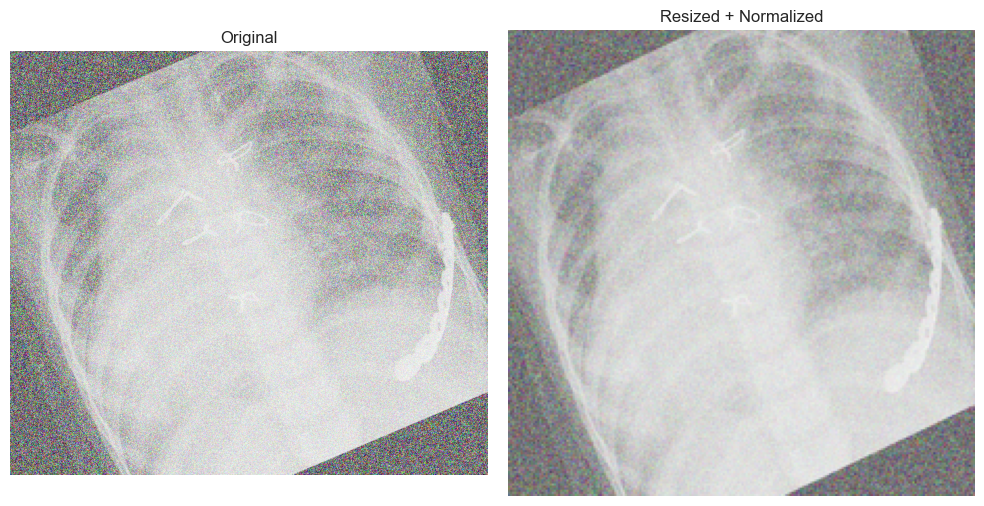

In [14]:
IMG_SIZE = (224, 224)  # compatible with DenseNet121 used later
def preprocess_image(filepath, target_size=IMG_SIZE):
    img = Image.open(filepath).convert("RGB")
    img = img.resize(target_size)
    return np.array(img) / 255.0

sample_path = df_clean[df_clean['class'] == 'PNEUMONIA']['filepath'].iloc[0]
processed = preprocess_image(sample_path)
print(f"Processed shape: {processed.shape}")
print(f"Pixel range: [{processed.min():.3f}, {processed.max():.3f}]")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(Image.open(sample_path), cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(processed); axes[1].set_title("Resized + Normalized"); axes[1].axis("off")
plt.tight_layout()
plt.show()

### 5.2 Data Augmentation Plan

Small rotations, shifts, zoom, and brightness changes — no horizontal flip, 
since X-ray anatomy should not be mirrored.

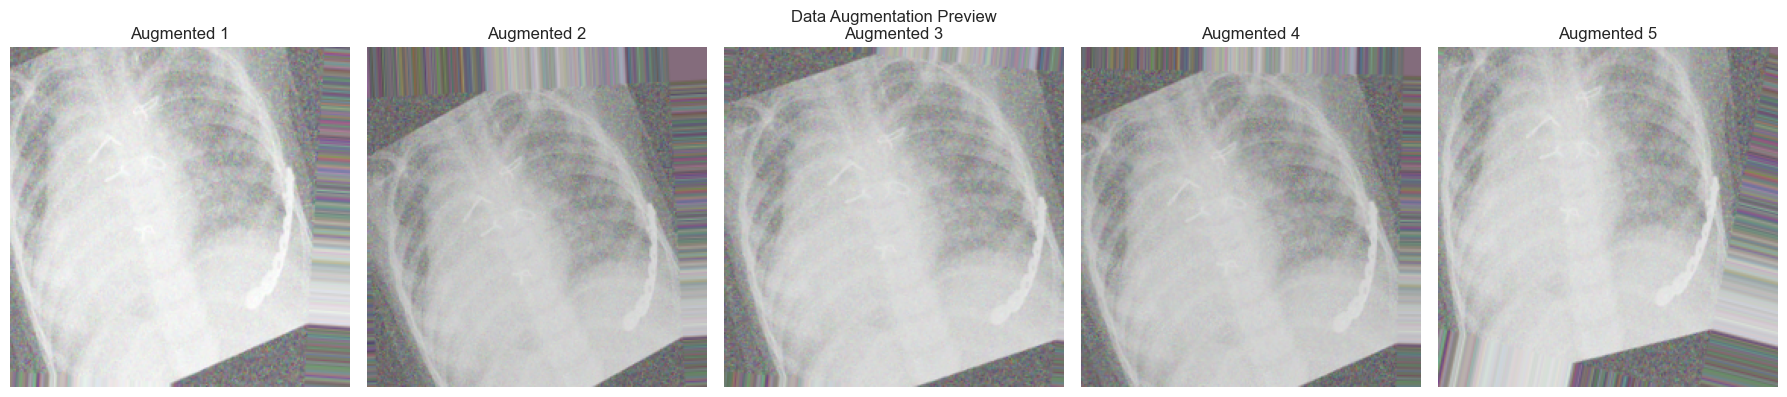

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=False
)

sample_img = np.array(Image.open(sample_path).convert("RGB").resize(IMG_SIZE))
sample_img = sample_img.reshape((1,) + sample_img.shape)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
i = 0
for batch in datagen.flow(sample_img, batch_size=1):
    axes[i].imshow(batch[0].astype("uint8"))
    axes[i].axis("off")
    axes[i].set_title(f"Augmented {i+1}")
    i += 1
    if i == 5:
        break
    
plt.suptitle("Data Augmentation Preview")
plt.tight_layout()
plt.show()

### 5.3 Save Cleaned Index

Save the cleaned file list

In [16]:
df_clean.to_csv("clean_dataset_index.csv", index=False)
print("Saved: clean_dataset_index.csv")

Saved: clean_dataset_index.csv


# Implementing Neural Network
## CNN

### Part 1: Setup and Load Cleaned Data

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)

tf.random.set_seed(42)
np.random.seed(42)
BASE_DIR = Path("chest_xray_balanced")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

### Part 2: Build Data Generators

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=False
)

val_test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    BASE_DIR / "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    BASE_DIR / "val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    BASE_DIR / "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 8000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


### Build CNN Architecture

In [19]:
def build_cnn(input_shape=(224, 224, 3)):
    
    model = Sequential([
        Conv2D(32, (3,3), activation="relu", input_shape=input_shape),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation="relu"),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation="relu"),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
    return model

model = build_cnn()
model.summary()

c:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

### Compile and Train (Baseline Configuration)

In [21]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 790s 3s/step - accuracy: 0.8494 - loss: 0.3366 - val_accuracy: 0.8725 - val_loss: 0.4077
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 997s 4s/step - accuracy: 0.8945 - loss: 0.2331 - val_accuracy: 0.8763 - val_loss: 0.4091
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 852s 3s/step - accuracy: 0.8940 - loss: 0.2328 - val_accuracy: 0.8763 - val_loss: 0.3040
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 706s 3s/step - accuracy: 0.9070 - loss: 0.2134 - val_accuracy: 0.8500 - val_loss: 0.3454
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 666s 3s/step - accuracy: 0.9147 - loss: 0.1969 - val_accuracy: 0.9312 - val_loss: 0.2035


### Plot Training Curves

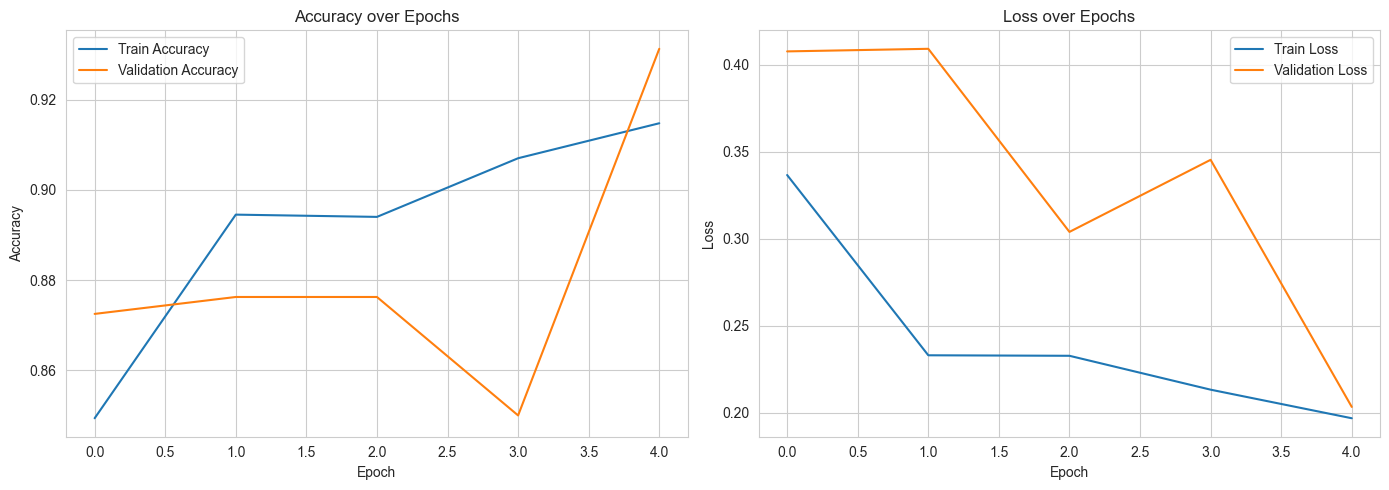

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
plt.tight_layout()
plt.show()

### Hyperparameter Tuning- Second Configuration

In [24]:
def build_cnn_v2(input_shape=(224, 224, 3)):
    model = Sequential([
        Conv2D(32, (3,3), activation="relu", input_shape=input_shape),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation="relu"),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation="relu"),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
    return model

model_v2 = build_cnn_v2()
model_v2.compile(
    optimizer=Adam(learning_rate=0.0005),   # lower learning rate
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

train_generator_v2 = train_datagen.flow_from_directory(
    BASE_DIR / "train", target_size=IMG_SIZE,
    batch_size=16,        # smaller batch size
    class_mode="binary", shuffle=True, seed=42
)

history_v2 = model_v2.fit(
    train_generator_v2,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop]
)

Found 8000 images belonging to 2 classes.
Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 706s 1s/step - accuracy: 0.8329 - loss: 0.3616 - val_accuracy: 0.8112 - val_loss: 0.4313
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 770s 2s/step - accuracy: 0.8857 - loss: 0.2553 - val_accuracy: 0.8950 - val_loss: 0.2916
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 870s 2s/step - accuracy: 0.9021 - loss: 0.2274 - val_accuracy: 0.8612 - val_loss: 0.3292
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 722s 1s/step - accuracy: 0.9079 - loss: 0.2105 - val_accuracy: 0.8413 - val_loss: 0.3889
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 905s 2s/step - accuracy: 0.9141 - loss: 0.1982 - val_accuracy: 0.9275 - val_loss: 0.2247


### Generate Predictions on the Test Set

In [25]:
# Use the better-performing model from Part 4 or Part 6 — assign it to `final_model`
final_model = model  # or model_v2, whichever performed better on validation data

test_generator.reset()
predictions_prob = final_model.predict(test_generator)
predictions = (predictions_prob > 0.5).astype(int).flatten()

true_labels = test_generator.classes
print(f"Total test predictions: {len(predictions)}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step
Total test predictions: 800


### Confusion Matrix

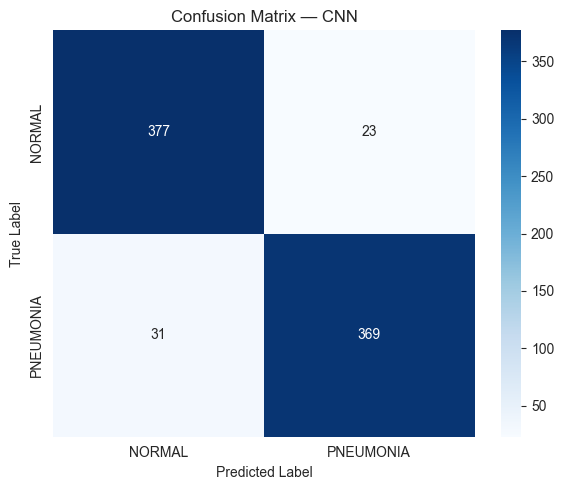

In [26]:
cm = confusion_matrix(true_labels, predictions)
class_names = list(test_generator.class_indices.keys())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix — CNN")
plt.tight_layout()
plt.show()

### Precision, Recall, F1-Score, and Accuracy

In [27]:
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nFull Classification Report:")
print(classification_report(true_labels, predictions, target_names=class_names))

Accuracy:  0.9325
Precision: 0.9413
Recall:    0.9225
F1-Score:  0.9318

Full Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.94      0.93       400
   PNEUMONIA       0.94      0.92      0.93       400

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



In [28]:
from sklearn.metrics import accuracy_score

test_accuracy_manual = accuracy_score(true_labels, predictions)
print(f"Test Accuracy (from predictions): {test_accuracy_manual:.4f}")

Test Accuracy (from predictions): 0.9325


In [29]:
test_loss, test_accuracy = final_model.evaluate(test_generator)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9325 - loss: 0.2182
Test Loss:     0.2182
Test Accuracy: 0.9325


### ROC Curve and AUC Score

25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 961ms/step


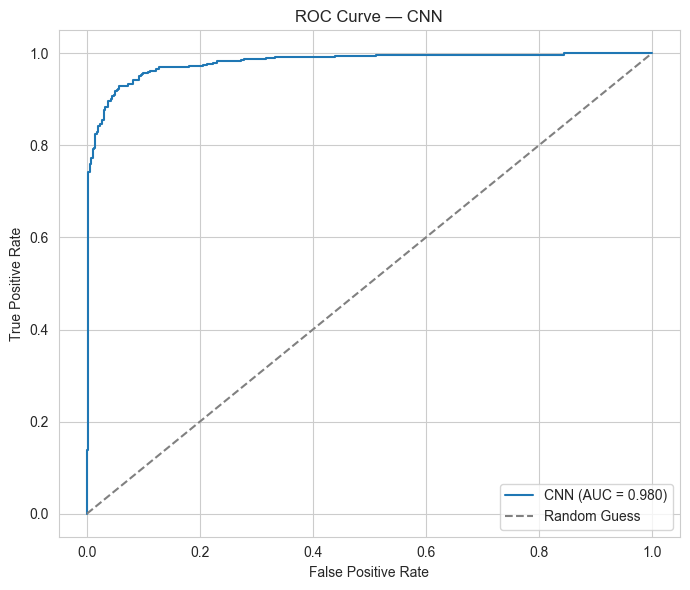

AUC Score: 0.9799


In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

# Ensure CNN prediction probabilities are available (from Part 7 of the CNN stage)
test_generator.reset()
predictions_prob_cnn = final_model.predict(test_generator)
true_labels_cnn = test_generator.classes

fpr_cnn, tpr_cnn, _ = roc_curve(true_labels_cnn, predictions_prob_cnn)
auc_cnn = roc_auc_score(true_labels_cnn, predictions_prob_cnn)

plt.figure(figsize=(7, 6))
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC = {auc_cnn:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — CNN")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_cnn:.4f}")

## Model 2: DenseNet121 (Transfer Learning)

### Part 1: Build the DenseNet121 Model

In [30]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # freeze pretrained layers initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

densenet_model = Model(inputs=base_model.input, outputs=output)
densenet_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

### Part 2: Compile and Train

In [31]:
densenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop_dn = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history_densenet = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop_dn]
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1724s 7s/step - accuracy: 0.8254 - loss: 0.3739 - val_accuracy: 0.7025 - val_loss: 0.4992
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1088s 4s/step - accuracy: 0.8896 - loss: 0.2440 - val_accuracy: 0.7850 - val_loss: 0.4096
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1107s 4s/step - accuracy: 0.9075 - loss: 0.2085 - val_accuracy: 0.8675 - val_loss: 0.3082
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1096s 4s/step - accuracy: 0.9178 - loss: 0.1915 - val_accuracy: 0.8800 - val_loss: 0.2893
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1485s 6s/step - accuracy: 0.9244 - loss: 0.1768 - val_accuracy: 0.8650 - val_loss: 0.3027


### Part 3: Training Curves

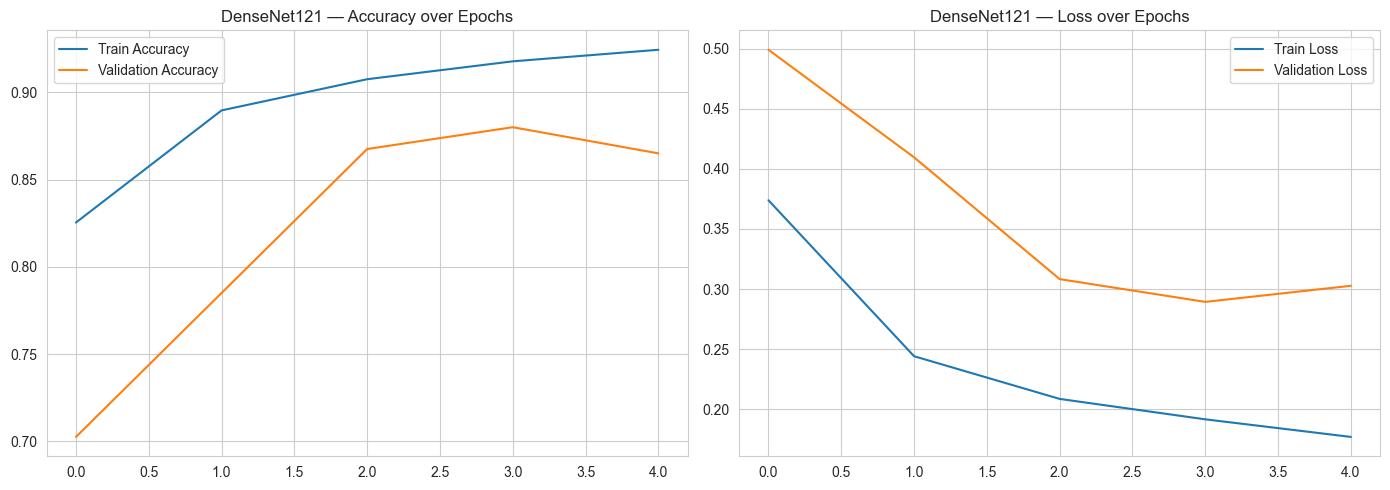

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_densenet.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_densenet.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title("DenseNet121 — Accuracy over Epochs")
axes[0].legend()

axes[1].plot(history_densenet.history['loss'], label='Train Loss')
axes[1].plot(history_densenet.history['val_loss'], label='Validation Loss')
axes[1].set_title("DenseNet121 — Loss over Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

### Part 4: Predictions on Test Set

In [33]:
test_generator.reset()
predictions_prob_dn = densenet_model.predict(test_generator)
predictions_dn = (predictions_prob_dn > 0.5).astype(int).flatten()

true_labels_dn = test_generator.classes

25/25 ━━━━━━━━━━━━━━━━━━━━ 120s 4s/step


### Part 5: Confusion Matrix

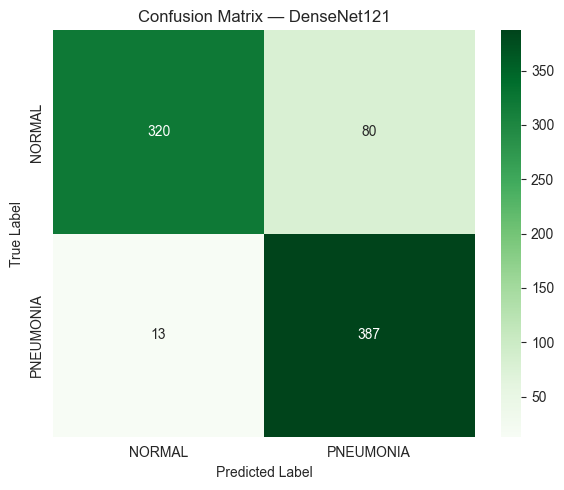

[[320  80]
 [ 13 387]]


In [34]:
cm_dn = confusion_matrix(true_labels_dn, predictions_dn)
class_names = list(test_generator.class_indices.keys())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_dn, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix — DenseNet121")
plt.tight_layout()
plt.show()
print(cm_dn)

### Part 6:  Precision, Recall, F1-Score, Accuracy

In [35]:
accuracy_dn = accuracy_score(true_labels_dn, predictions_dn)
precision_dn = precision_score(true_labels_dn, predictions_dn)
recall_dn = recall_score(true_labels_dn, predictions_dn)
f1_dn = f1_score(true_labels_dn, predictions_dn)

print(f"DenseNet121 — Accuracy:  {accuracy_dn:.4f}")
print(f"DenseNet121 — Precision: {precision_dn:.4f}")
print(f"DenseNet121 — Recall:    {recall_dn:.4f}")
print(f"DenseNet121 — F1-Score:  {f1_dn:.4f}")

DenseNet121 — Accuracy:  0.8838
DenseNet121 — Precision: 0.8287
DenseNet121 — Recall:    0.9675
DenseNet121 — F1-Score:  0.8927


### Part 7: ROC Curve and AUC Score

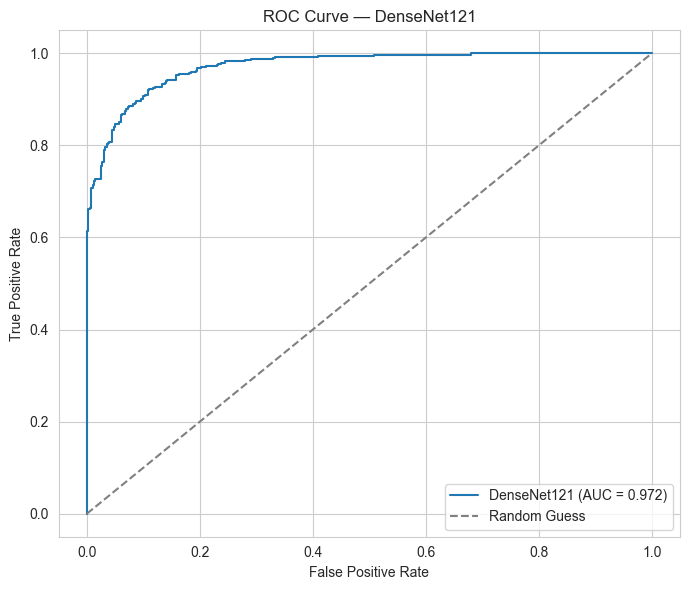

AUC Score: 0.9716


In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_dn, tpr_dn, _ = roc_curve(true_labels_dn, predictions_prob_dn)
auc_dn = roc_auc_score(true_labels_dn, predictions_prob_dn)

plt.figure(figsize=(7, 6))
plt.plot(fpr_dn, tpr_dn, label=f"DenseNet121 (AUC = {auc_dn:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — DenseNet121")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_dn:.4f}")

## Model 3: Randon Forest on DenseNet121 Features

### Part 1: Extract Feature Vectors Using DenseNet121

In [37]:
from tensorflow.keras.applications.densenet import preprocess_input

feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

def extract_features(generator, extractor):
    generator.reset()
    features = []
    labels = []
    steps = len(generator)
    for i in range(steps):
        batch_x, batch_y = next(generator)
        batch_features = extractor.predict(batch_x, verbose=0)
        batch_features = batch_features.reshape(batch_features.shape[0], -1)
        features.append(batch_features)
        labels.append(batch_y)
    return np.vstack(features), np.concatenate(labels)

train_features, train_labels = extract_features(train_generator, feature_extractor)
val_features, val_labels = extract_features(val_generator, feature_extractor)
test_features, test_labels = extract_features(test_generator, feature_extractor)

print(f"Train feature shape: {train_features.shape}")
print(f"Test feature shape:  {test_features.shape}")

Train feature shape: (8000, 50176)
Test feature shape:  (800, 50176)


### Part 2: Train the Random Forest Classifier

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(train_features, train_labels)
print("Random Forest training complete.")

Random Forest training complete.


### Part 3: Prediction on Test Set

In [39]:
predictions_rf = rf_model.predict(test_features)
predictions_prob_rf = rf_model.predict_proba(test_features)[:, 1]

### Part 4: Confusion Matrix

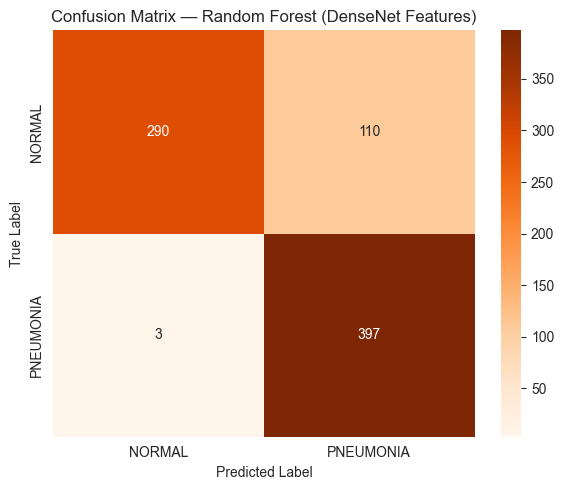

[[290 110]
 [  3 397]]


In [40]:
cm_rf = confusion_matrix(test_labels, predictions_rf)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix — Random Forest (DenseNet Features)")
plt.tight_layout()
plt.show()
print(cm_rf)

### Part 5: Precision, Recall, F1-Score, and Accuracy

In [41]:
accuracy_rf = accuracy_score(test_labels, predictions_rf)
precision_rf = precision_score(test_labels, predictions_rf)
recall_rf = recall_score(test_labels, predictions_rf)
f1_rf = f1_score(test_labels, predictions_rf)

print(f"Random Forest — Accuracy:  {accuracy_rf:.4f}")
print(f"Random Forest — Precision: {precision_rf:.4f}")
print(f"Random Forest — Recall:    {recall_rf:.4f}")
print(f"Random Forest — F1-Score:  {f1_rf:.4f}")

Random Forest — Accuracy:  0.8588
Random Forest — Precision: 0.7830
Random Forest — Recall:    0.9925
Random Forest — F1-Score:  0.8754


### Part 6: ROC Curve and AUC Score

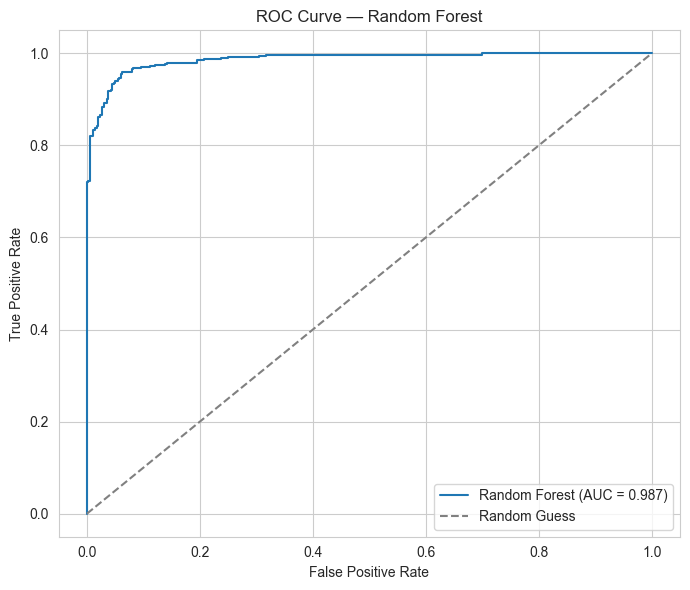

AUC Score: 0.9867


In [44]:
fpr_rf, tpr_rf, _ = roc_curve(test_labels, predictions_prob_rf)
auc_rf = roc_auc_score(test_labels, predictions_prob_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_rf:.4f}")

## Comparison Table and Overlaid ROC Curves

                               Model  Accuracy  Precision  Recall  F1-Score  \
0                                CNN   0.93250   0.941327  0.9225  0.931818   
1                        DenseNet121   0.88375   0.828694  0.9675  0.892734   
2  Random Forest (DenseNet Features)   0.85875   0.783037  0.9925  0.875413   

        AUC  
0  0.979888  
1  0.971569  
2  0.986700  


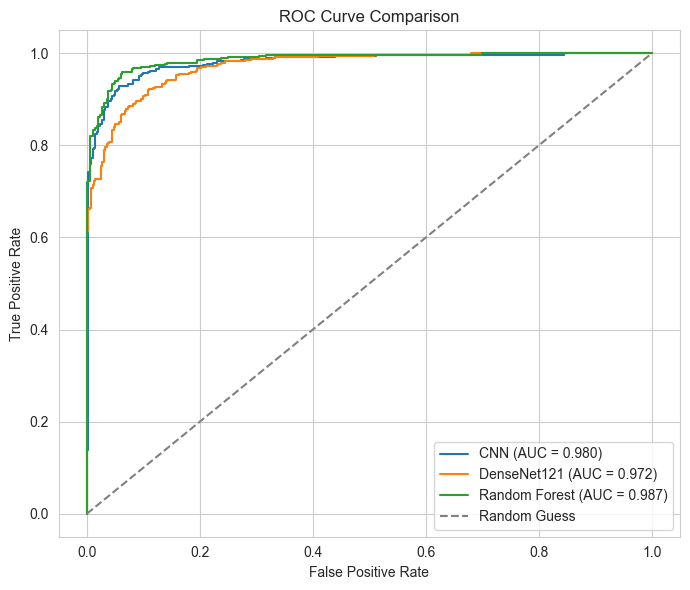

In [47]:
comparison_df = pd.DataFrame({
    "Model": ["CNN", "DenseNet121", "Random Forest (DenseNet Features)"],
    "Accuracy": [accuracy, accuracy_dn, accuracy_rf],
    "Precision": [precision, precision_dn, precision_rf],
    "Recall": [recall, recall_dn, recall_rf],
    "F1-Score": [f1, f1_dn, f1_rf],
    "AUC": [auc_cnn, auc_dn, auc_rf]
})

print(comparison_df)

plt.figure(figsize=(7, 6))
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC = {auc_cnn:.3f})")
plt.plot(fpr_dn, tpr_dn, label=f"DenseNet121 (AUC = {auc_dn:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()